In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [107]:
df = pd.read_csv("data/player_data_COMPLETE.csv")

Filtramos para que nos salgan únicamente los jugadores de la posición que queremos

In [108]:
df_fw = df[df["main_position"].isin(["CF", "FW"])].copy()
df_clustering = df_fw[df_fw["low_minutes_flag"] == False].copy()

Selección de métricas

In [109]:
features_clustering = [
    # gol
    "goals_avg",
    
    # eficiencia
    "shot_efficiency_avg",
    
    # juego asociativo
    "xg_assist_avg",
    
    # presencia ofensiva
    "real_progression",
    
    # físico
    "aerial_duels_won_avg",
    
    # desequilibrio
    "dribble_efficiency",

    "successful_defensive_actions_avg",

    "touch_in_box_avg"

]

X = df_clustering[features_clustering].fillna(0)

Escalado

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [111]:
df_scaled = pd.DataFrame(X_scaled, columns=features_clustering)
print("\nDatos estandarizados:")
print(df_scaled.head())


Datos estandarizados:
   goals_avg  shot_efficiency_avg  xg_assist_avg  real_progression  \
0   0.573175             0.300815       1.505276         -0.626120   
1   0.371790             0.222997      -1.196955         -0.830575   
2  -1.088253            -0.633003       2.180834          2.037635   
3   0.824906             2.246267      -1.028065          1.027043   
4  -0.030981             0.300815      -1.365844          0.255956   

   aerial_duels_won_avg  dribble_efficiency  successful_defensive_actions_avg  \
0              0.753545            0.804478                         -0.647550   
1             -0.169543           -0.330535                          0.021845   
2             -0.218540            3.520164                          1.263854   
3             -0.734733            1.333681                          0.473485   
4             -0.590194            1.235180                          1.029969   

   touch_in_box_avg  
0          0.372400  
1          0.412729  
2  

PCA: Reducción de dimensionalidad

In [112]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)

[0.33226501 0.2352916  0.14413363]


In [113]:
n_components = 3
pca_clustering = pd.DataFrame(data=X_pca, columns=[f'PC{i}' for i in range(1, n_components+1)])
print("\nComponentes principales:")
print(pca_clustering.head())


Componentes principales:
        PC1       PC2       PC3
0  0.745564 -0.820641 -0.830547
1 -0.728899 -0.888601  0.319603
2  3.370098  2.993429 -0.943889
3  1.552125 -0.418130  2.322413
4  0.260267  0.800059  1.265323


C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the

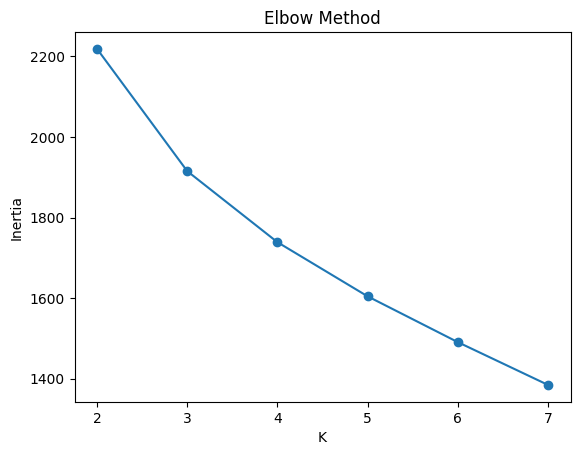

In [114]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

In [115]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_clustering["cb_cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Germán Llorente\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [116]:
cluster_profile = df_clustering.groupby("cb_cluster")[features_clustering].mean()
print(cluster_profile)

            goals_avg  shot_efficiency_avg  xg_assist_avg  real_progression  \
cb_cluster                                                                    
0            0.235843            -0.094943       0.060058          2.067388   
1            0.199519            -0.035941       0.079738          4.140902   
2            0.405104             0.007156       0.182773          5.629641   
3            0.543000             0.109539       0.065408          2.400417   

            aerial_duels_won_avg  dribble_efficiency  \
cb_cluster                                             
0                       2.512068            0.703163   
1                       1.211447            1.333124   
2                       0.943727            2.039638   
3                       1.689163            0.837618   

            successful_defensive_actions_avg  touch_in_box_avg  
cb_cluster                                                      
0                                   2.947052          3.16

In [117]:
cols_show = ["name", "market_value", "minutes_on_field", "cb_cluster"]

df_cb_view = df_clustering[cols_show].sort_values(
    ["cb_cluster", "market_value"],
    ascending=[True, False]
)

for c in sorted(df_clustering["cb_cluster"].unique()):
    print(f"\n--- CLUSTER {c} ---")
    display(df_cb_view[df_cb_view["cb_cluster"] == c].head(10))


--- CLUSTER 0 ---


,name,market_value,minutes_on_field,cb_cluster
2757,O. Watkins,65000000.0,2973,0
2924,C. Nkunku,65000000.0,1169,0
3298,D. Vlahović,65000000.0,1594,0
1157,E. Ferguson,50000000.0,787,0
1626,Gonçalo Ramos,50000000.0,1920,0
3695,J. David,50000000.0,2385,0
2702,D. Solanke,40000000.0,1592,0
751,N. Jackson,35000000.0,1796,0
1221,E. Wahi,35000000.0,1926,0
1883,R. Lukaku,30000000.0,2230,0



--- CLUSTER 1 ---


,name,market_value,minutes_on_field,cb_cluster
3889,D. Núñez,70000000.0,1091,1
3310,Lucas Paquetà,65000000.0,2819,1
2840,Mikel Merino,50000000.0,1953,1
3886,J. Zirkzee,50000000.0,1291,1
734,M. Tel,40000000.0,1363,1
399,Vitor Roque,30000000.0,696,1
1129,A. Adli,30000000.0,1126,1
1389,E. Millot,30000000.0,1244,1
2943,Hwang Hee-Chan,25000000.0,925,1
3605,N. Zaniolo,20000000.0,1274,1



--- CLUSTER 2 ---


,name,market_value,minutes_on_field,cb_cluster
2928,K. Mbappé,180000000.0,3362,2
1619,J. Álvarez,90000000.0,2931,2
3343,L. Díaz,75000000.0,3063,2
2758,M. Thuram,65000000.0,1883,2
3114,V. Gyökeres,65000000.0,4084,2
2751,J. Bowen,50000000.0,3432,2
1679,C. De Ketelaere,34000000.0,2040,2
2916,E. Nketiah,30000000.0,842,2
1907,A. Griezmann,25000000.0,2174,2
3445,A. Gouiri,25000000.0,1953,2



--- CLUSTER 3 ---


,name,market_value,minutes_on_field,cb_cluster
3336,E. Haaland,180000000.0,2906,3
3362,R. Kolo Muani,45000000.0,1551,3
3041,D. Malen,40000000.0,1494,3
3093,Richarlison,38000000.0,1269,3
3401,F. Balogun,30000000.0,916,3
2695,Y. Wissa,28000000.0,2669,3
2958,E. Demirović,28000000.0,1984,3
1201,Igor Thiago,25000000.0,1339,3
2290,A. Sørloth,25000000.0,1587,3
2932,V. Pavlidis,25000000.0,1402,3


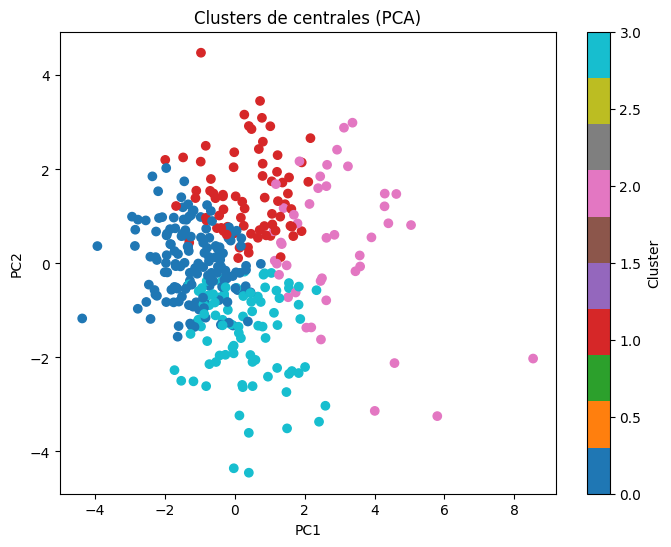

In [118]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df_clustering["cb_cluster"],
    cmap="tab10"
)

plt.title("Clusters de centrales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")
plt.show()

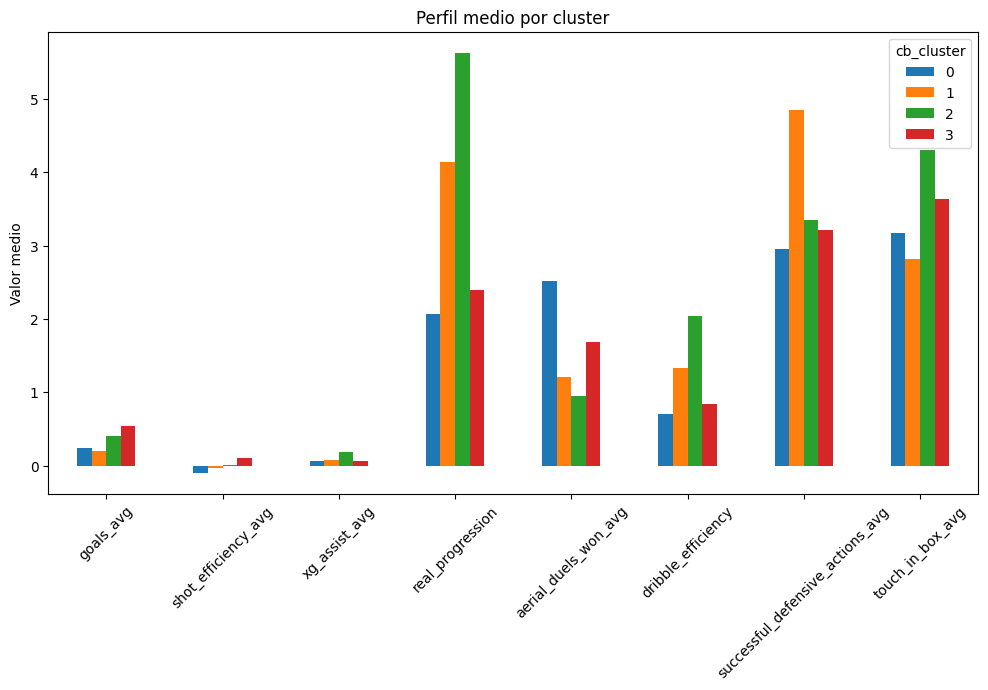

In [119]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))
plt.title("Perfil medio por cluster")
plt.xticks(rotation=45)
plt.ylabel("Valor medio")
plt.show()

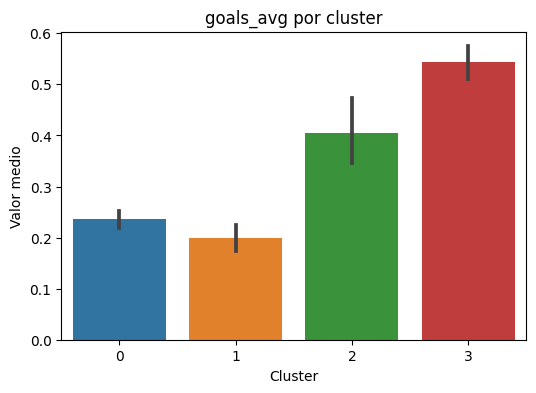

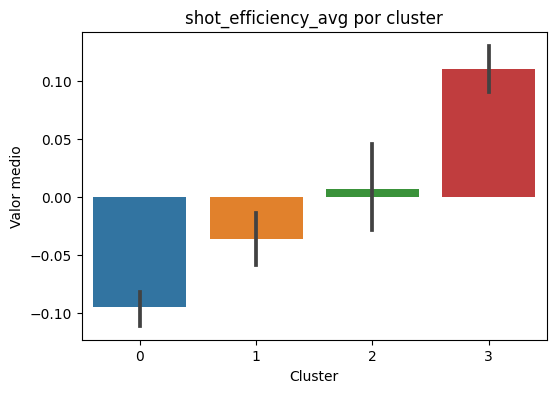

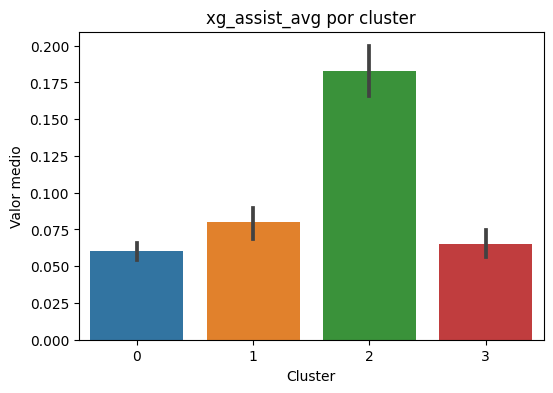

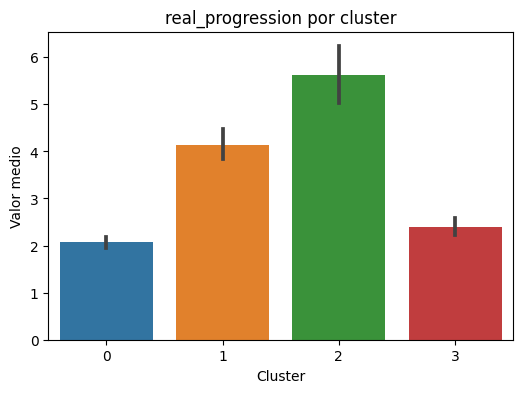

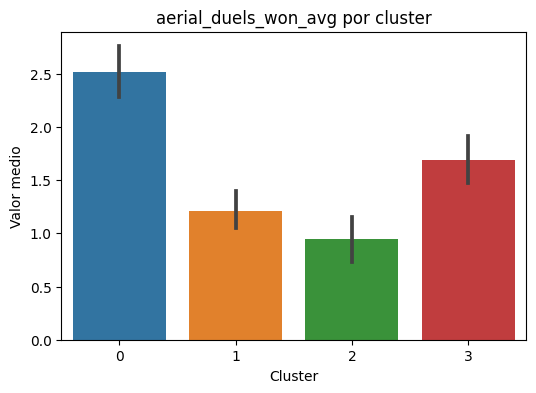

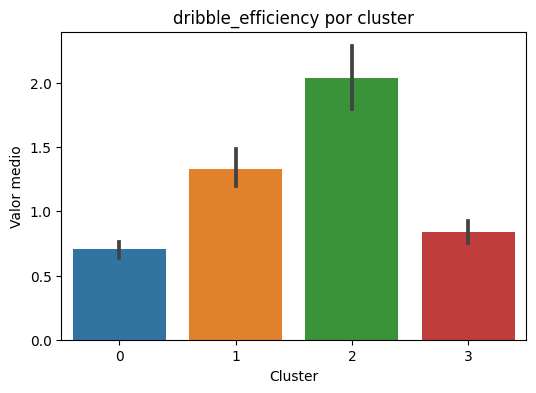

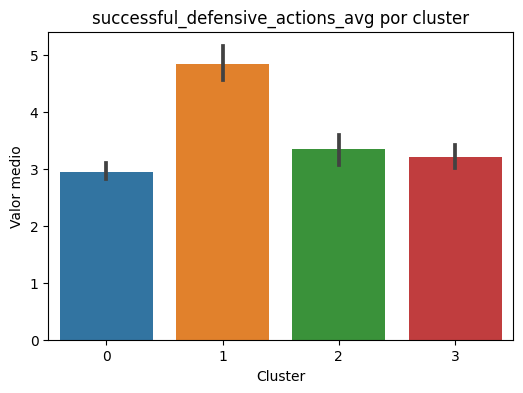

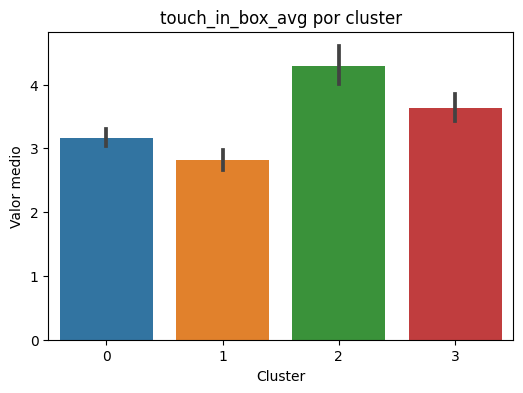

In [120]:
for col in features_clustering:
    
    plt.figure(figsize=(6,4))
    
    sns.barplot(
        x="cb_cluster",
        y=col,
        data=df_clustering
    )
    
    plt.title(f"{col} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Valor medio")
    
    plt.show()

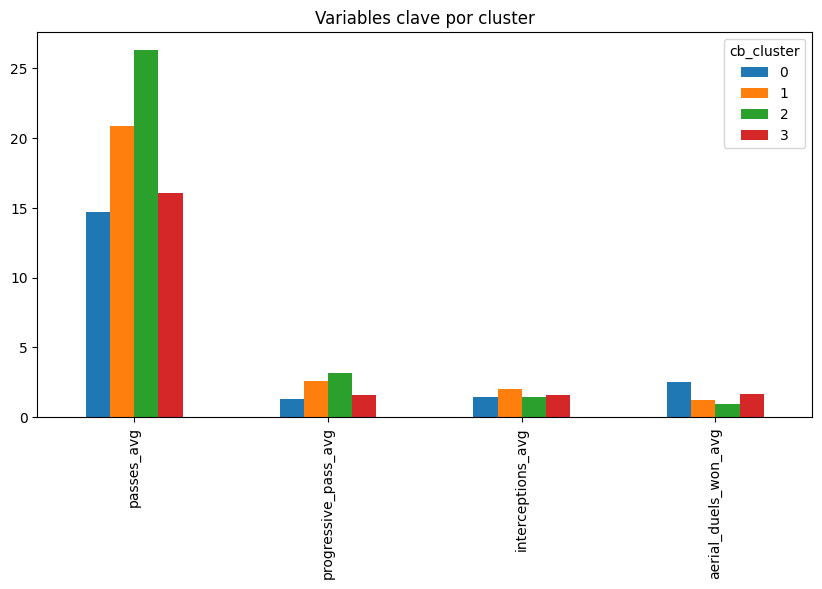

In [121]:
key_vars = [
    "passes_avg",
    "progressive_pass_avg",
    "interceptions_avg",
    "aerial_duels_won_avg"
]

df_clustering.groupby("cb_cluster")[key_vars].mean().T.plot(kind="bar", figsize=(10,5))
plt.title("Variables clave por cluster")
plt.show()

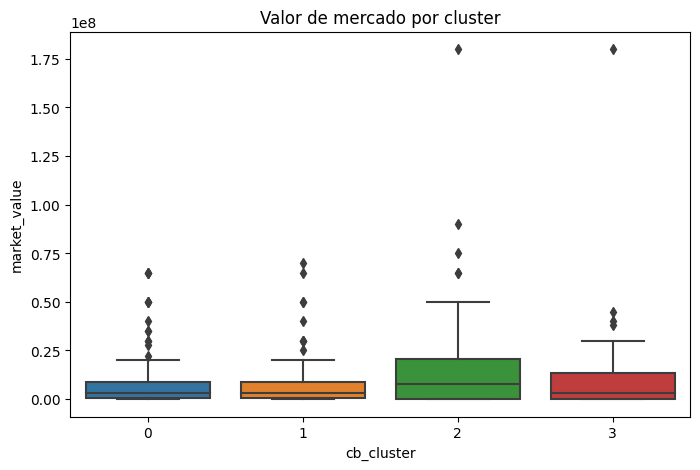

In [122]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cb_cluster", y="market_value", data=df_clustering)
plt.title("Valor de mercado por cluster")
plt.show()

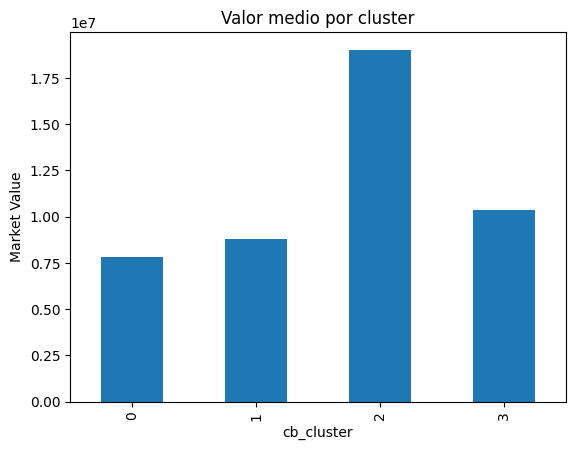

In [123]:
df_clustering.groupby("cb_cluster")["market_value"].mean().plot(kind="bar")

plt.title("Valor medio por cluster")
plt.ylabel("Market Value")
plt.show()

In [124]:
loadings = pd.DataFrame(
    pca.components_,
    columns=features_clustering,
    index=["PC1", "PC2", "PC3"]
)

display(loadings)

,goals_avg,shot_efficiency_avg,xg_assist_avg,real_progression,aerial_duels_won_avg,dribble_efficiency,successful_defensive_actions_avg,touch_in_box_avg
PC1,0.265924,0.246905,0.439565,0.482921,-0.375825,0.449118,0.052546,0.310128
PC2,-0.603490,-0.411065,0.096245,0.324090,-0.112989,0.231599,0.413935,-0.338794
PC3,0.182378,0.612651,-0.253268,0.063529,-0.146408,-0.102899,0.494820,-0.496333


cluster_labels = {
    0: "Target forward",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Goal scoring forward"
}


In [125]:
cb_labels = {
    0: "Ball-stealing CB",
    1: "Ball-playing CB",
    2: "Aerial dominant CB",
    3: "Low-impact CB"
}

fb_labels = {
    0: "Attacking full-back (goal threat)",
    1: "Creative full-back",
    2: "Low-impact full-back",
    3: "Defensive full-back"
}

mf_labels = {
    0: "Attacking midfielder",
    1: "Low-impact midfielder",
    2: "Deep-lying playmaker",
    3: "Ball-winning midfielder"
}

w_labels = {
    0: "Dribbler winger",
    1: "Low-impact winger",
    2: "Defensive winger",
    3: "Goal-scoring winger"
}

fw_labels = {
    0: "Target man",
    1: "Pressing forward",
    2: "Creative forward",
    3: "Goal scoring forward"
}

gk_labels = {
    0: "Low-performing GK",
    1: "Shot-stopper GK",
    2: "Ball-playing GK",
    3: "Low-impact GK"
}

def assign_role(row):
  
    return fw_labels.get(row["cb_cluster"])


df_clustering["player_role"] = df_clustering.apply(assign_role, axis=1)

In [126]:
df_clustering[["id", "name", "cb_cluster", "player_role"]].to_csv("clustering/data/fw_clusters.csv", index=False)